In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Read in the csv file, only reading in 100,000 rows for efficiency and setting the state for reproducibility.
The final model will be trained using the whole dataset.

In [5]:
file_path = "/Users/adityasingh/Documents/credit-risk-analysis/data/loan.csv"

loans_df = pd.read_csv(file_path).sample(100000, random_state=42)


/var/folders/h6/t51zpc7x1g9b5jb_bhqvmzsm0000gp/T/ipykernel_12349/3435190441.py:3: DtypeWarning: Columns (19,55) have mixed types. Specify dtype option on import or set low_memory=False.
  loans_df = pd.read_csv(file_path).sample(100000, random_state=42)


In [6]:
print(loans_df.columns)

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose',
       'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
       'total_rec_int', 'total_rec_late_fee', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
       'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'policy_code', 'application_type',
       'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    

Going to impute columns where over 50% of the data is missing.

In [7]:
def findMissingValueCols(df):

    missing_val_cols = []
    total_rows = len(df)

    for column in df.columns:
        null_rows = df[column].isna().sum()
        print(column, "--", null_rows*100/total_rows, "%")

        if null_rows > total_rows * 0.5:
            missing_val_cols.append(column)

    return missing_val_cols

cols_to_drop = findMissingValueCols(loans_df)

loans_clean = loans_df.drop(columns=cols_to_drop)

id -- 0.0 %
member_id -- 0.0 %
loan_amnt -- 0.0 %
funded_amnt -- 0.0 %
funded_amnt_inv -- 0.0 %
term -- 0.0 %
int_rate -- 0.0 %
installment -- 0.0 %
grade -- 0.0 %
sub_grade -- 0.0 %
emp_title -- 5.763 %
emp_length -- 5.015 %
home_ownership -- 0.0 %
annual_inc -- 0.0 %
verification_status -- 0.0 %
issue_d -- 0.0 %
loan_status -- 0.0 %
pymnt_plan -- 0.0 %
url -- 0.0 %
desc -- 85.76 %
purpose -- 0.0 %
title -- 0.018 %
zip_code -- 0.0 %
addr_state -- 0.0 %
dti -- 0.0 %
delinq_2yrs -- 0.001 %
earliest_cr_line -- 0.001 %
inq_last_6mths -- 0.001 %
mths_since_last_delinq -- 51.143 %
mths_since_last_record -- 84.723 %
open_acc -- 0.001 %
pub_rec -- 0.001 %
revol_bal -- 0.0 %
revol_util -- 0.046 %
total_acc -- 0.001 %
initial_list_status -- 0.0 %
out_prncp -- 0.0 %
out_prncp_inv -- 0.0 %
total_pymnt -- 0.0 %
total_pymnt_inv -- 0.0 %
total_rec_prncp -- 0.0 %
total_rec_int -- 0.0 %
total_rec_late_fee -- 0.0 %
recoveries -- 0.0 %
collection_recovery_fee -- 0.0 %
last_pymnt_d -- 2.07 %
last_pymnt_a

In [8]:
print(loans_clean.dtypes)

id                              int64
member_id                       int64
loan_amnt                       int64
funded_amnt                     int64
funded_amnt_inv               float64
term                           object
int_rate                      float64
installment                   float64
grade                          object
sub_grade                      object
emp_title                      object
emp_length                     object
home_ownership                 object
annual_inc                    float64
verification_status            object
issue_d                        object
loan_status                    object
pymnt_plan                     object
url                            object
purpose                        object
title                          object
zip_code                       object
addr_state                     object
dti                           float64
delinq_2yrs                   float64
earliest_cr_line               object
inq_last_6mt

To create a clean binary credit risk model, only loans with the status "Fully Paid" or "Charged Off" will be kept.

In [9]:
loans_clean = loans_clean[loans_clean["loan_status"].isin(["Fully Paid", "Charged Off"])]

Creating a target variable so that 0 = Good borrower and 1 = Default

In [10]:
loans_clean["target"] = loans_clean["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

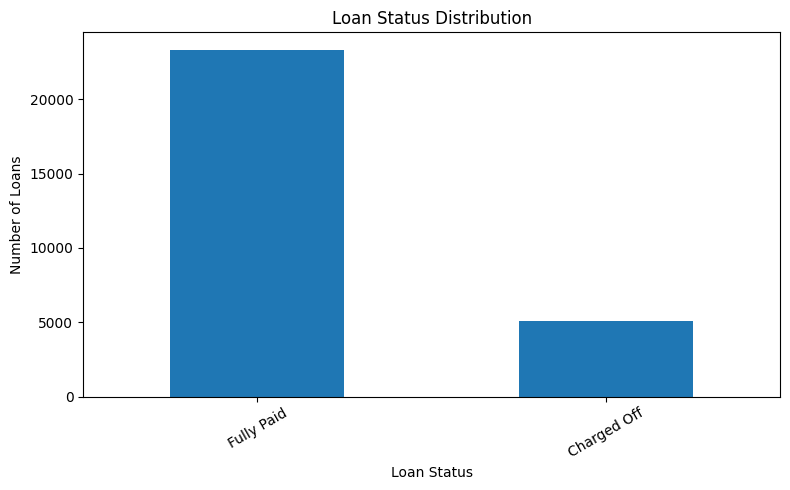

In [11]:
plt.figure(figsize=(8,5))

loans_clean["loan_status"].value_counts().plot(kind="bar")

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Investigating the relationship between interest rate and loan status/default rate.

Loans which are charged off, or defaulted, tend to have a higher interest rate, this is likely due to lenders charging a higher interest rate to compensate for a higher likelihood that they will not be repaid.

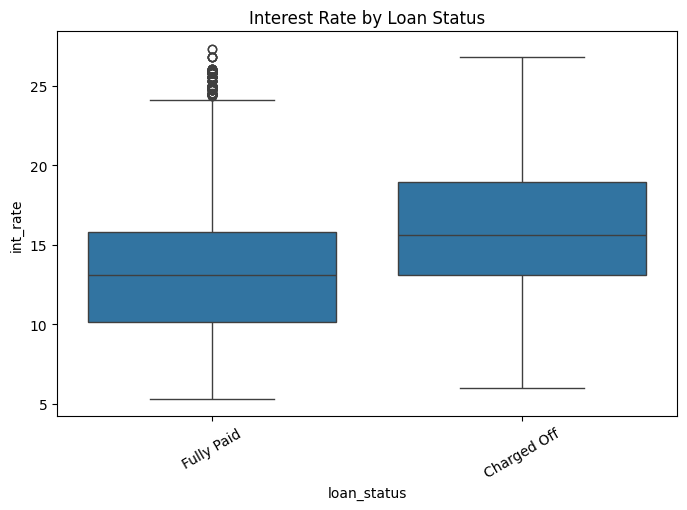

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x="loan_status", y="int_rate", data=loans_clean)

plt.title("Interest Rate by Loan Status")
plt.xticks(rotation=30)
plt.show()

/Users/adityasingh/Library/Python/3.9/lib/python/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


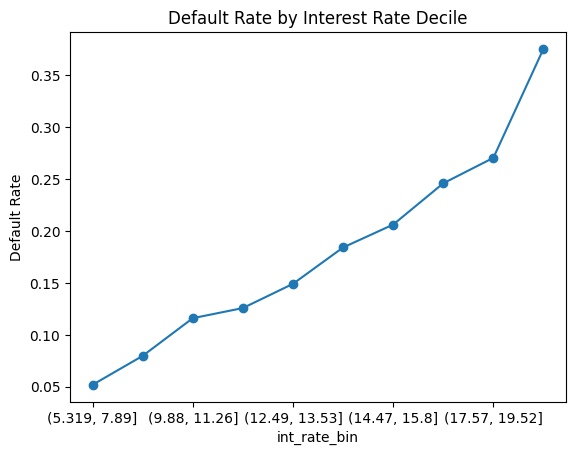

In [13]:
def default_rate_by_feature(df, feature):
    return pd.crosstab(
        df[feature],
        df["loan_status"],
        normalize="index"
    )

loans_clean["int_rate_bin"] = pd.qcut(loans_clean["int_rate"], 10)

default_table = default_rate_by_feature(loans_clean, "int_rate_bin")

default_table["Charged Off"].plot(marker="o")
plt.title("Default Rate by Interest Rate Decile")
plt.ylabel("Default Rate")
plt.show()

Next the relationship between loan default rates and the borrower's credit risk grde.

As expected, the better the grade (with A being the best), the lower the default rate.

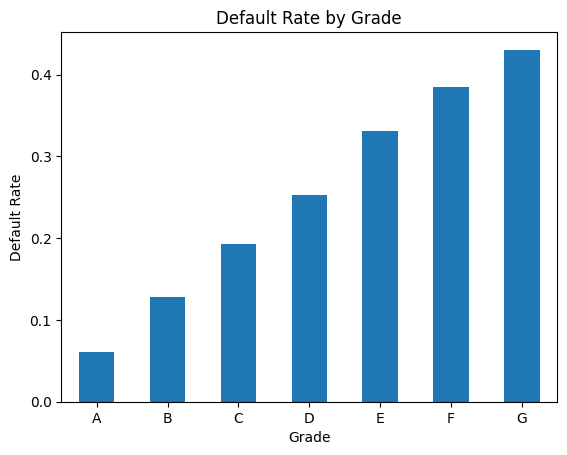

In [14]:
grade_table = default_rate_by_feature(loans_clean, "grade")

grade_table["Charged Off"].plot(kind="bar")

plt.title("Default Rate by Grade")
plt.ylabel("Default Rate")
plt.xlabel("Grade")
plt.xticks(rotation=0)
plt.show()

By observing the relationship between loan term and loan default rate, a clear positive relationship can be seen.

This is due to factors such as; more chance of negative events occuring, high interest rates and aging risk.

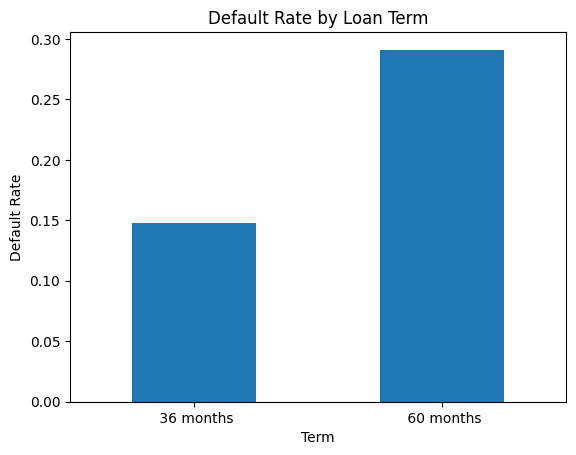

In [15]:
term_table = default_rate_by_feature(loans_clean, "term")

term_table["Charged Off"].plot(kind="bar")

plt.title("Default Rate by Loan Term")
plt.ylabel("Default Rate")
plt.xlabel("Term")
plt.xticks(rotation=0)
plt.show()

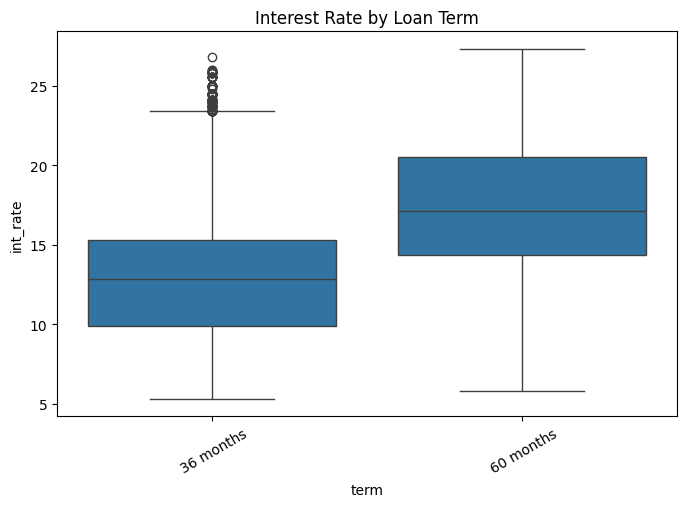

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x="term", y="int_rate", data=loans_clean)

plt.title("Interest Rate by Loan Term")
plt.xticks(rotation=30)
plt.show()

Clear positive relationship can be observed between debt-to-income ration and default rate as high-DTI borrowers are more likely to fall behind on repayments, as a larger portion of their income is already committed to servicing existing debt and they are more susceptible to being severely impacted by an adverse event.

/Users/adityasingh/Library/Python/3.9/lib/python/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


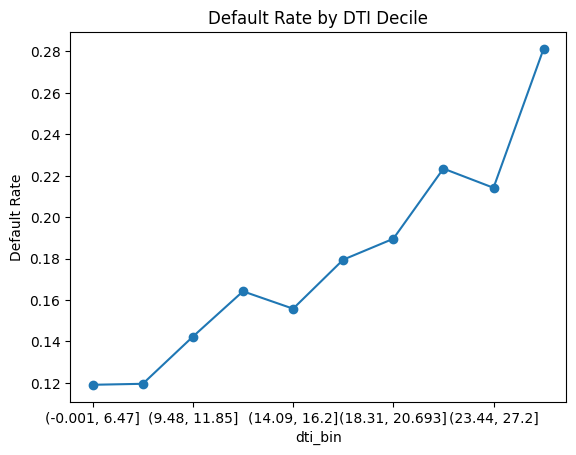

In [17]:
loans_clean["dti_bin"] = pd.qcut(loans_clean["dti"], 10)

default_table = pd.crosstab(
    loans_clean["dti_bin"],
    loans_clean["loan_status"],
    normalize="index"
)

default_table["Charged Off"].plot(marker="o")
plt.title("Default Rate by DTI Decile")
plt.ylabel("Default Rate")
plt.show()


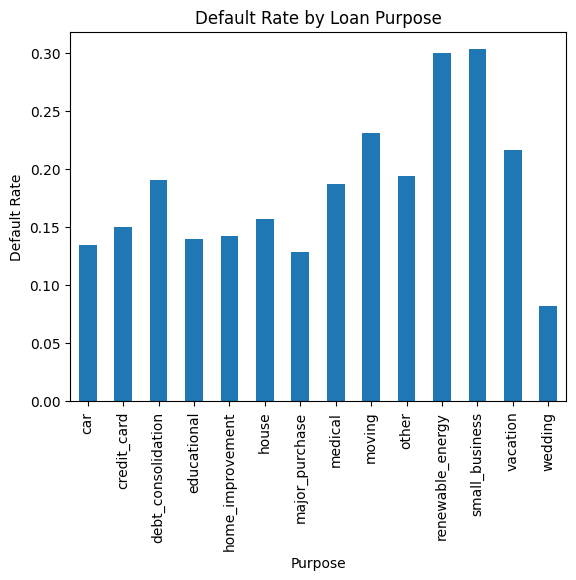

In [18]:
purpose_table = default_rate_by_feature(loans_clean, "purpose")

purpose_table["Charged Off"].plot(kind="bar")

plt.title("Default Rate by Loan Purpose")
plt.ylabel("Default Rate")
plt.xlabel("Purpose")
plt.xticks(rotation='vertical')
plt.show()

Investigating the relationship between annual income and loan default rate, using a log transformation for normalisation as income is right/positively skewed.

The line graph shows that there is an inverse relationship between annual income and default rate.

/Users/adityasingh/Library/Python/3.9/lib/python/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


loan_status       Charged Off  Fully Paid
income_bin                               
(8.699, 10.41]       0.238916    0.761084
(10.41, 10.614]      0.217101    0.782899
(10.614, 10.779]     0.207851    0.792149
(10.779, 10.915]     0.179789    0.820211
(10.915, 11.035]     0.195661    0.804339
(11.035, 11.156]     0.174461    0.825539
(11.156, 11.29]      0.164184    0.835816
(11.29, 11.462]      0.156912    0.843088
(11.462, 11.695]     0.127638    0.872362
(11.695, 15.98]      0.124025    0.875975


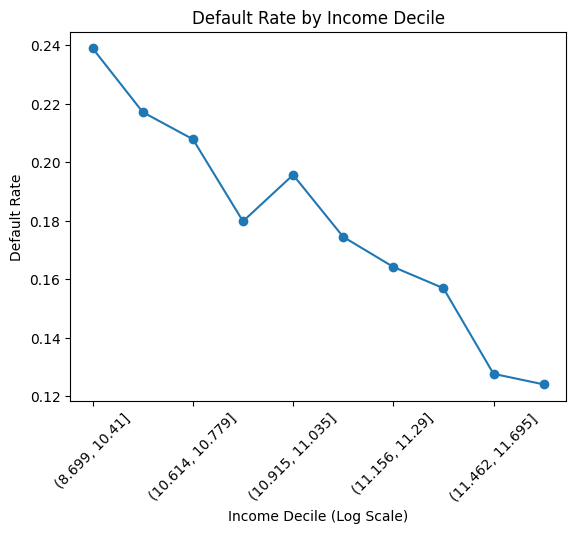

In [19]:
loans_clean["log_income"] = np.log1p(loans_clean["annual_inc"])

loans_clean["income_bin"] = pd.qcut(
    loans_clean["log_income"],
    10,
    duplicates="drop"
)

income_table = pd.crosstab(
    loans_clean["income_bin"],
    loans_clean["loan_status"],
    normalize="index"
)

print(income_table)

income_table["Charged Off"].plot(marker="o")

plt.title("Default Rate by Income Decile")
plt.ylabel("Default Rate")
plt.xlabel("Income Decile (Log Scale)")
plt.xticks(rotation=45)
plt.show()

Looking at the relationship between utility and default rates, a monotonic relationship can be seen as the default rate increases and revolving utility increases

/Users/adityasingh/Library/Python/3.9/lib/python/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


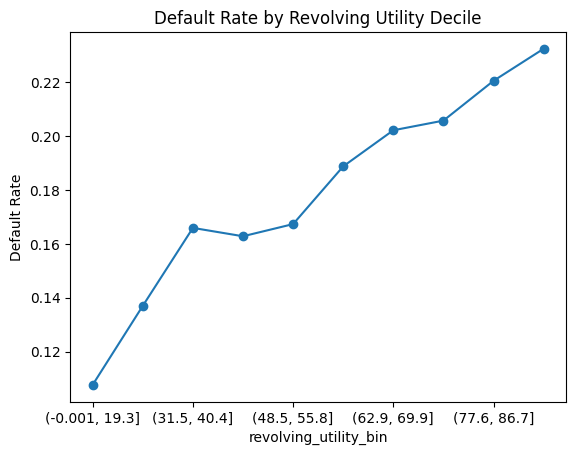

In [22]:
loans_clean["revolving_utility_bin"] = pd.qcut(loans_clean["revol_util"], 10)

default_table = default_rate_by_feature(loans_clean, "revolving_utility_bin")

default_table["Charged Off"].plot(marker="o")
plt.title("Default Rate by Revolving Utility Decile")
plt.ylabel("Default Rate")
plt.show()